## Introduction to Linear Filters

Juan Diego Perez Navarro  
T00067699  
Universidad Tecnológica de Bolívar

In [39]:
from scipy import signal
from scipy import datasets
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import skimage

## Brief Theory of Linear Filters

Tamaño Original:  (512, 512)


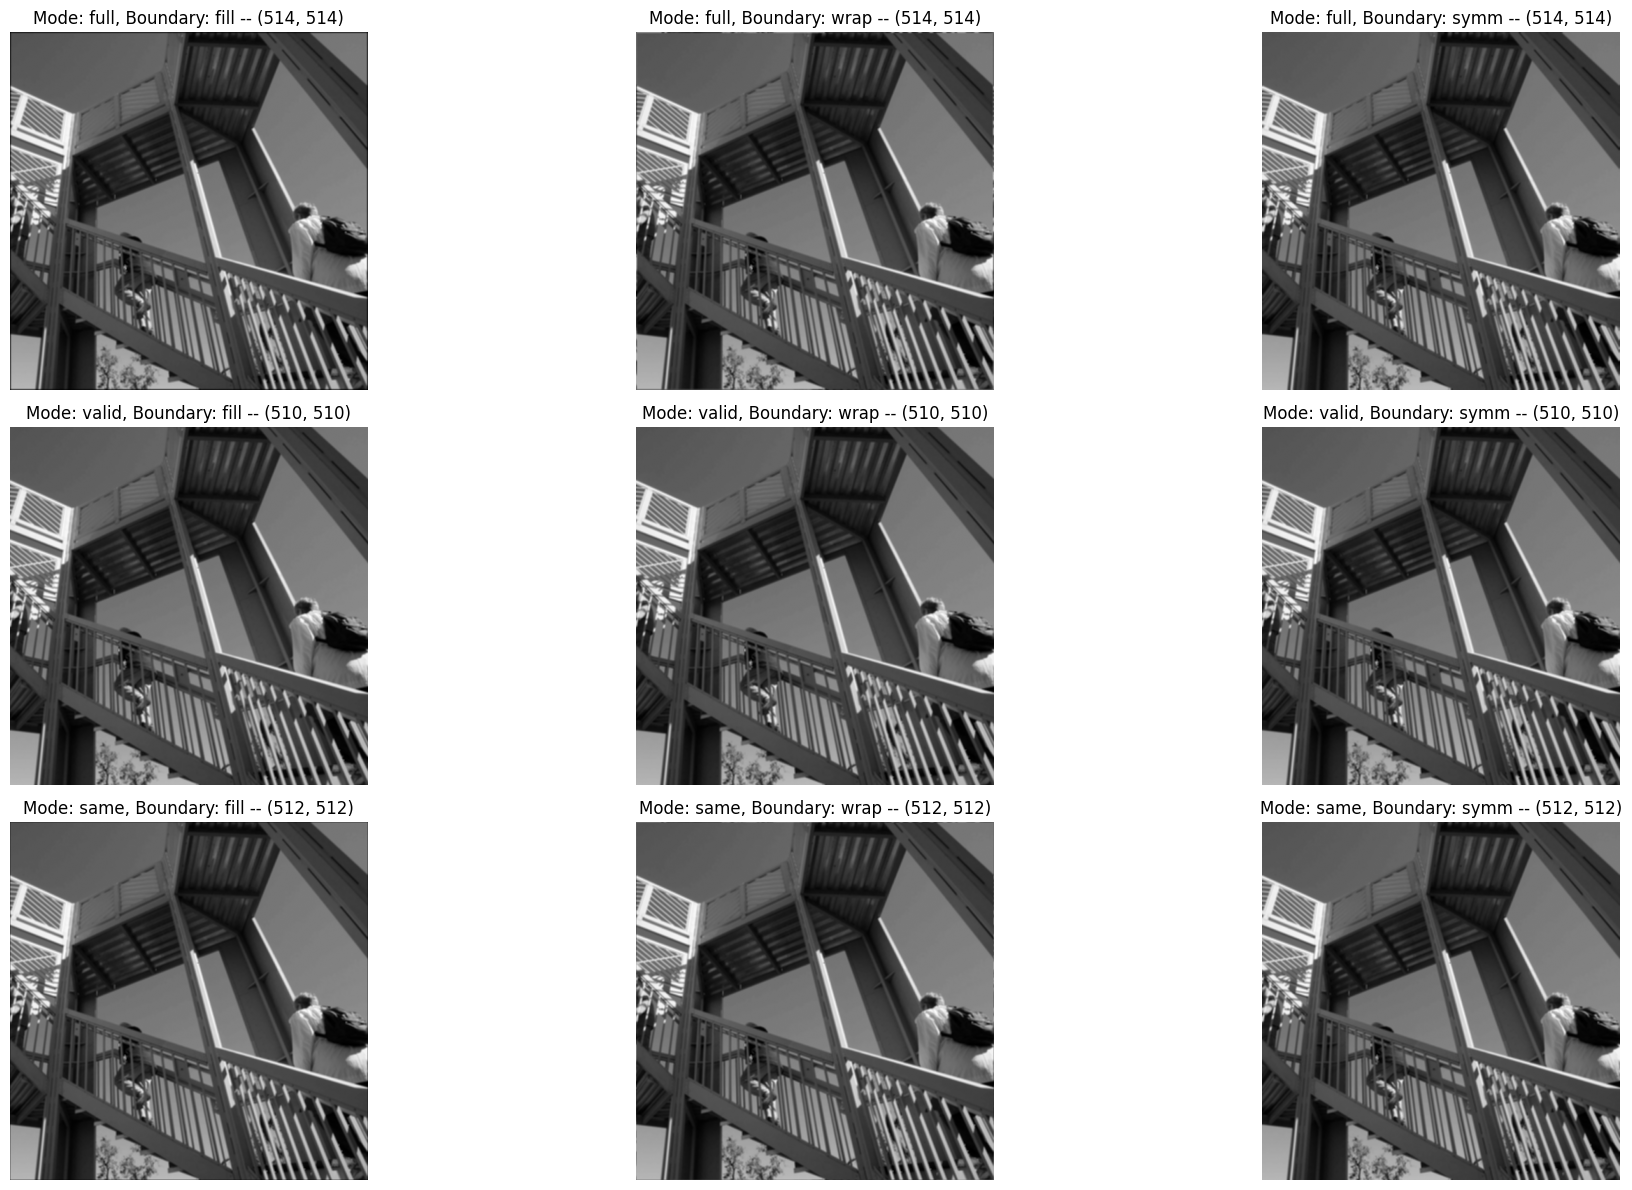

In [40]:
image = np.uint8(datasets.ascent())
print("Tamaño Original: ", image.shape)

box_fil = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) * 1/9

sigma = 1
image_gaussian_filtered = gaussian_filter(image, sigma=sigma)

MODES = ["full", "valid", "same"]
BOUNDARIES = ["fill", "wrap", "symm"]

fig, axes = plt.subplots(3, 3, figsize=(21, 12))

for mode, row in zip(MODES, axes):
    for boundary, ax in zip(BOUNDARIES, row):
        image_filtered = signal.convolve2d(image, box_fil, boundary=boundary, mode=mode)
        ax.imshow(image_filtered, cmap="gray")
        ax.set_title(f"Mode: {mode}, Boundary: {boundary} -- {image_filtered.shape}")
        ax.axis("off")

fig.tight_layout()
plt.show()

Relacionado a lo que mencionó el profesor en clases, esto es lo que entiendo que hacen esos parametros:

Mode: Se refiere a cómo hacer la convolución.
* `full`. Realiza la convolución de tal manera que el filtro se interseque lo mínimo con la imagen original, lo que ocasiona que la imagen quede de tamaño mayor a la original.
* `valid`. Aquí la convolución se hace como originalmente se debería hacer, el kernel queda completamente dentro de la imagen, lo que provoca que el tamaño resultante sea menor a la original.
* `same`. Finalmente, con este modo lo que se hace es un punto medio de los anteriores. A la hora de hacer de convolución se hace de tal manera que el resultado sea del mismo tamaño de la imagen original.

Boundary: Cómo manejar los bordes
* `fill`. Los bordes que se toman de la convolución que no hacen parte de la imagen original se colocan como el parametro `fillvalue` se le especifique (por defecto, 0).
* `wrap` & `symm`. No termino de entender muy bien la diferencia entre ambos, pero sí se puede notar que con `wrap` queda un poco más feo en los bordes (al menos, a mi criterio), como si se trate de una especie de espejo. Con `symm` se ve más limpio.

Con `mode="valid"` no aplica ninguno de los boundary, pues aquí nunca se utilizan esos bordes que se agregan.

## Let's Add Noise to the Image and Filter It

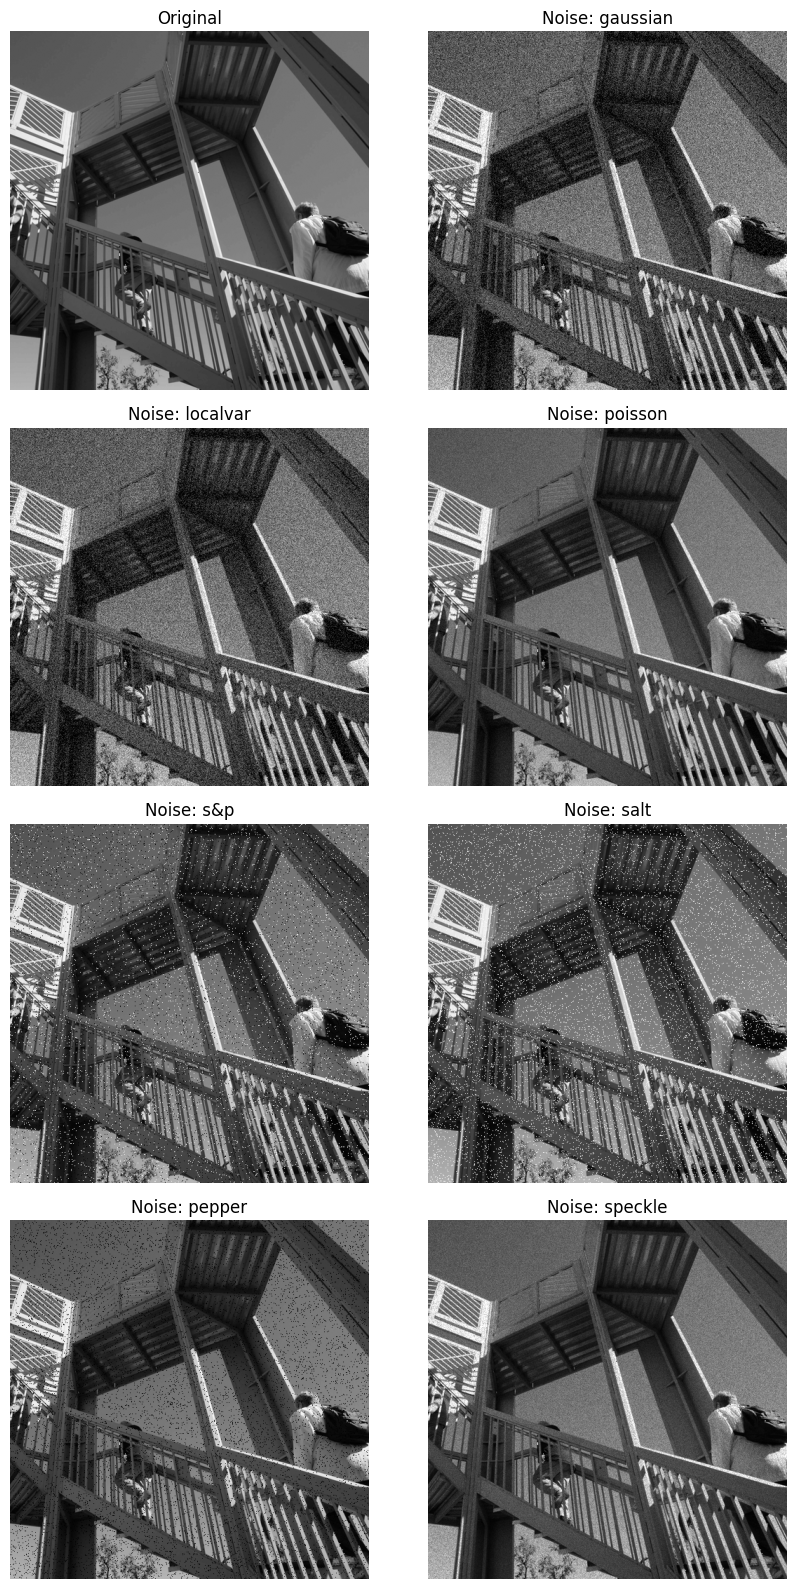

In [41]:
NOISE = ["gaussian", "localvar", "poisson", "s&p", "salt", "pepper", "speckle"]
fig, axes = plt.subplots(4, 2, figsize=(9, 16))

axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for noise, ax in zip(NOISE, axes.flatten()[1:]):
    image_noised = skimage.util.random_noise(image, mode=noise)
    ax.imshow(image_noised, cmap="gray")
    ax.set_title(f"Noise: {noise}")
    ax.axis("off")

fig.tight_layout()
plt.show()

## Applying a Median Filter to Remove Noise

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


C:\Users\JuanD\AppData\Local\Temp\ipykernel_31672\2160115670.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


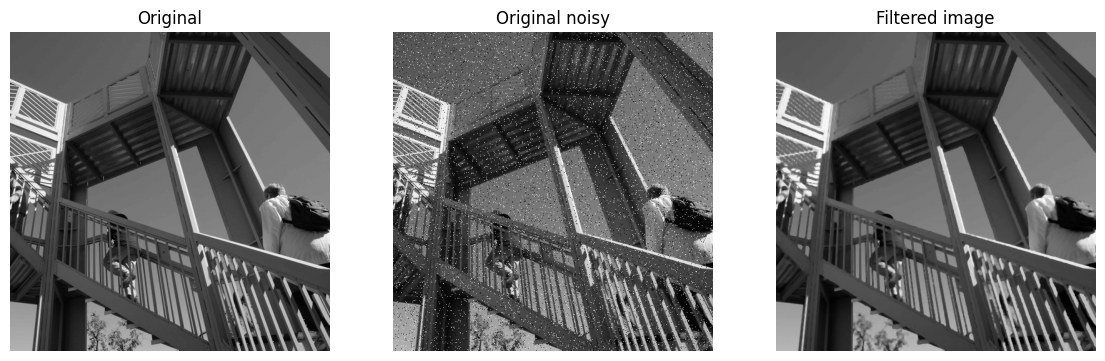

In [58]:
# Let's try other types of filters

from skimage.morphology import disk

image_noised = skimage.util.random_noise(image, mode="s&p")
med = skimage.filters.median(image_noised, disk(2))
print(disk(2))

fig, (ax_orig, ax_noised, ax_mag) = plt.subplots(1, 3, figsize=(14, 21))
ax_orig.imshow(image, cmap='gray')
ax_orig.set_title('Original')
ax_orig.set_axis_off()

ax_noised.imshow(image_noised, cmap='gray')
ax_noised.set_title('Original noisy')
ax_noised.set_axis_off()

ax_mag.imshow(med, cmap='gray')
ax_mag.set_title('Filtered image')
ax_mag.set_axis_off()
fig.show()